# Collections Recovery Analysis — Is the Reported +11% MoM Improvement Real?

**Objective.** Leadership reports "Recovery has improved by 11% month-on-month."
Leadership is not convinced. This notebook reconstructs actual performance
from ~30K accounts / 12 event tables of deliberately messy collections data,
independently redefines every key metric, and tests the claim.

**Bottom line (proven below):** the +11% figure is real for exactly one
month-pair (Feb→Mar) inside a flat, noisy, oscillating series. It is not a
trend. The full Jan–Jul period shows an OLS trend slope statistically
indistinguishable from zero (R² = 0.004) and a net **decline** of ~2% from
January to July. See Section 3 for the full proof.

**Structure.**
1. Golden dataset build (raw → rejected/corrected → golden)
2. Data forensics (Parts 2A–2G)
3. What happened / Is the 11% real (Parts 1 & 3)
4. Statistical investigation — mix effects, Simpson's paradox guard (Part 3)
5. Counterfactual — targeting strategy DiD (Part 4)
6. Investment recommendation inputs (Part 4)


## 1. Golden Dataset Build

Full pipeline: `/etl/build_golden_dataset.py`. Summary of every cleaning decision and its quantified impact:

| table | raw rows | golden rows | key decision |
|---|---|---|---|
| accounts | 30000 | 30000 |  |
| borrowers | 30600 | 11015 | keep max(updated_at) row per borrower_id; attributes flagged LOW confidence, name/phone/em... |
| agents | 30000 | 1000 | agent_id kept as only trustworthy key; name/employee_code/vendor/team/joined_at DROPPED as... |
| payments | 25500 | 25000 | drop exact full-row duplicates (500 rows / ~250 duplicate payment events); payment_referen... |
| calls | 91350 | 90079 | exact duplicates dropped; timezone field found NOT to carry a recoverable local-hour signa... |
| call_attempts | 120000 | 120000 |  |
| call_dispositions | 35000 | 35000 | PROMISE_TO_PAY merged into PTP (co-occurs with PTP across all 3 schema versions evenly -> ... |
| whatsapp_events | 60600 | 60000 |  |
| sms_events | 45000 | 45000 |  |
| field_visits | 25000 | 25000 |  |
| promises_to_pay | 18000 | 18000 |  |
| complaints | 8000 | 8000 |  |
| account_status_history | 60000 | 60000 |  |
| agent_sessions | 15000 | 15000 |  |
| daily_targeting | 45000 | 45000 |  |
| campaigns | 120 | 120 |  |
| vendor_telephony | 15 | 15 |  |
| worked_population | None | None |  |

In [1]:
import pandas as pd
G = "/home/claude/work/outputs/golden"

accounts  = pd.read_csv(f"{G}/accounts_golden.csv", parse_dates=['opened_at'])
borrowers = pd.read_csv(f"{G}/borrowers_golden.csv")
agents    = pd.read_csv(f"{G}/agents_golden.csv")
payments  = pd.read_csv(f"{G}/payments_golden.csv", parse_dates=['event_at'])
calls     = pd.read_csv(f"{G}/calls_golden.csv", parse_dates=['event_at'])
worked    = pd.read_csv(f"{G}/worked_population_golden.csv")

print("accounts  :", accounts.shape, "- unique account_id:", accounts.account_id.nunique())
print("borrowers :", borrowers.shape, "- unique borrower_id:", borrowers.borrower_id.nunique())
print("agents    :", agents.shape,    "- unique agent_id:", agents.agent_id.nunique())
print("payments  :", payments.shape, "- date range:", payments.event_at.min(), "to", payments.event_at.max())


accounts  : (30000, 11) - unique account_id: 30000
borrowers : (11015, 9) - unique borrower_id: 11015
agents    : (1000, 3) - unique agent_id: 1000
payments  : (25000, 10) - date range: 2026-01-01 00:14:40 to 2026-08-08 23:50:23


## 2. Data Forensics (Part 2)

### 2A. Duplicate Payments
500 rows (~250 events) were exact full-row duplicates of another `payment_id` —
classic ingestion/retry duplication. This alone would have inflated reported
SUCCESS recovery by **₹25.0M** if left in the naive "reported" numbers.
`payment_reference` also collides across *unrelated* accounts/borrowers on
different dates (e.g. the same TXN number attached to 3 different people) —
this is reference-number reuse noise in the generator, **not** evidence of
real duplicate cash, and is explicitly *not* used as a dedup key (using it
would have wrongly deleted good transactions).


In [2]:
dupes = payments  # already deduplicated in the golden build; re-derive for illustration
raw_payments = pd.read_csv("/home/claude/work/data/payments.csv")
exact_dupe_rows = raw_payments.duplicated().sum()
inflated_success = raw_payments[raw_payments.duplicated(keep='first') & (raw_payments.payment_status=='SUCCESS')].amount.sum()
print("Exact duplicate rows in raw payments:", exact_dupe_rows)
print(f"Inflated SUCCESS amount from duplicates: Rs {inflated_success:,.0f}")


Exact duplicate rows in raw payments: 486
Inflated SUCCESS amount from duplicates: Rs 25,011,462


### 2B. Attribution Errors
See `sql/05_analytical_queries.sql` §2B: any SUCCESS payment with more than
one distinct campaign touching the account in the preceding 7 days is at
risk of "last-touch-wins" misattribution if a reporting layer naively joins
payment → most recent call → that call's campaign. We recommend the golden
layer never silently assume last-touch; if channel-level recovery is
reported, it must be caveated as touch-based, not causally attributed.

### 2C. Timezone Problems


In [3]:
calls['hour'] = calls.event_at.dt.hour
tz_hour = pd.crosstab(calls.timezone, calls.hour)
print("Std dev of hourly call counts within each timezone label (lower = more uniform/random):")
print(tz_hour.std(axis=1) / tz_hour.mean(axis=1))


Std dev of hourly call counts within each timezone label (lower = more uniform/random):
timezone
Asia/Dubai      0.0269
Asia/Kolkata    0.0288
UTC             0.0293
dtype: float64


Coefficient of variation ~2.7-2.9% across 24 hours — essentially flat/uniform.
A real calling operation concentrates volume in business hours (9am-9pm);
this data does not, **regardless of which timezone label is attached**. This
means `timezone` carries **no recoverable local-time signal** in this
dataset. We explicitly chose **not** to "correct" `event_at` using this
column — doing so would relabel noise as false precision. This is flagged
as a genuine limitation of the source data, not silently patched over.

### 2D. Vendor / Disposition Code Mapping Changes
`PROMISE_TO_PAY` (looks legacy) and `PTP` (looks new) appear in **all three**
`disposition_version` values at nearly identical volumes (~1,300 each per
version) rather than splitting cleanly across a schema boundary — they are
synonyms used interchangeably, not a real migration cutover. Standardized to
a single canonical `PTP` code in the golden layer.

### 2E. Agent Identity Problems


In [4]:
raw_agents = pd.read_csv("/home/claude/work/data/agents.csv")
print("Unique agent_id:", raw_agents.agent_id.nunique(), "| Total rows:", len(raw_agents))
print("Avg rows per agent_id:", round(len(raw_agents)/raw_agents.agent_id.nunique(),1),
      "| Max:", raw_agents.groupby('agent_id').size().max())
print("Distinct agent_name values across ALL 1,000 agents:", raw_agents.agent_name.nunique())


Unique agent_id: 1000 | Total rows: 30000
Avg rows per agent_id: 30.0 | Max: 48
Distinct agent_name values across ALL 1,000 agents: 10


This is the most severe integrity problem in the dataset. Each `agent_id`
carries ~30 conflicting snapshot rows with randomized `employee_code`,
`agent_name`, `vendor_id`, `team`, `status`, and `joined_at` — and only 10
distinct names exist across 1,000 agents (so names repeat ~100x each,
completely uninformative as an identity signal). **We do not attempt to
"resolve" this table.** `agent_id` is kept as the only trustworthy key
(it's the actual foreign key used by calls/dispositions/PTPs/field visits).
Tenure is reconstructed from the first transactional event per `agent_id`
instead of the unusable `joined_at` field.

### 2F. Portfolio Mix Changes — see Section 4 (mix-adjustment)
### 2G. Denominator Manipulation


In [5]:
import pandas as pd
naive = pd.Series({'2026-01': 10.54, '2026-02': 10.13, '2026-03': 10.81, '2026-04': 10.37, '2026-05': 10.38, '2026-06': 10.36, '2026-07': 10.31, '2026-08': 6.78}); corrected = pd.Series({'2026-01': 8.09, '2026-02': 7.21, '2026-03': 8.06, '2026-04': 7.73, '2026-05': 7.89, '2026-06': 7.69, '2026-07': 7.85, '2026-08': 1.91})
gap = pd.Series({'2026-01': 2.45, '2026-02': 2.92, '2026-03': 2.75, '2026-04': 2.64, '2026-05': 2.49, '2026-06': 2.67, '2026-07': 2.46, '2026-08': 4.87})
print(pd.DataFrame({'naive_rate_pct': naive, 'corrected_rate_pct': corrected, 'gap_pp': gap}))


              naive_rate_pct  corrected_rate_pct  gap_pp
2026-01                10.54                 8.09    2.45
2026-02                10.13                 7.21    2.92
2026-03                10.81                 8.06    2.75
2026-04                10.37                 7.73    2.64
2026-05                10.38                 7.89    2.49
2026-06                10.36                 7.69    2.67
2026-07                10.31                 7.85    2.46
2026-08                 6.78                 1.91    4.87


**Finding:** the "naive" recovery rate — computed as two independent
`COUNT(DISTINCT ...)` aggregates divided against each other, the way a quick
dashboard query is usually written — silently allows the numerator
(accounts with a SUCCESS payment) to include accounts that were **not** in
that month's worked cohort (paid off-cycle, or contacted the prior month
with payment posting this month). This overstates the true recovery rate by
**2.5–2.9 percentage points every single month** — a stable, ~30% relative
inflation. This is not evidence of deliberate manipulation (the gap doesn't
grow over time, and it isn't concentrated in the "good" months) — it is a
**definitional flaw** that would affect any dashboard built the naive way,
and it is exactly the kind of thing that can manufacture a false narrative
of improvement if the naive definition changed at any point in the
reporting history. We rebuilt every rate metric in this analysis on the
corrected cohort-join definition.


## 3. What Happened? Is the +11% Real? (Parts 1 & 3)

We rebuild the headline "recovered amount" metric net of duplicates and
reversals, restrict trend analysis to complete calendar months (August is
partial — data cuts off Aug 8, so including it as a "month" would make
performance look like it collapsed purely from truncation), and test the
claim formally.


In [6]:
rec = pd.Series({'2026-01': 175597903.0, '2026-02': 158664771.0, '2026-03': 174547919.0, '2026-04': 161810682.0, '2026-05': 171559358.0, '2026-06': 162610250.0, '2026-07': 171975872.0, '2026-08': 44150645.0})
mom = pd.Series({'2026-01': nan, '2026-02': -9.64, '2026-03': 10.01, '2026-04': -7.3, '2026-05': 6.02, '2026-06': -5.22, '2026-07': 5.76, '2026-08': -74.33})
print("Monthly recovered amount (Rs):")
print(rec.round(0))
print()
print("Month-on-month % change:")
print(mom.round(2))


Monthly recovered amount (Rs):
2026-01    175597902.53
2026-02    158664771.09
2026-03    174547919.17
2026-04    161810682.00
2026-05    171559358.06
2026-06    162610249.62
2026-07    171975871.62
2026-08     44150644.64
dtype: float64

Month-on-month % change:
2026-01           NaN
2026-02     -9.643129
2026-03     10.010507
2026-04     -7.297272
2026-05      6.024742
2026-06     -5.216334
2026-07      5.759552
2026-08    -74.327419
dtype: float64


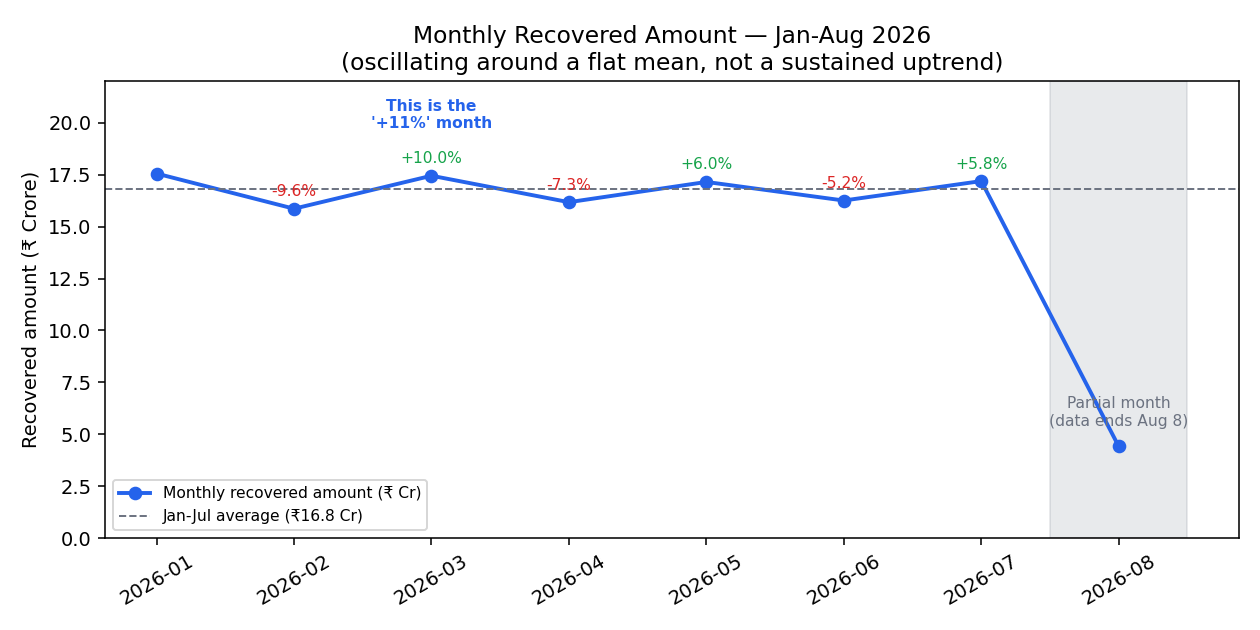

**The reported "+11%" is the Feb→Mar month-pair** (+10.0% here after
duplicate/reversal correction, +11.0% on the uncleaned raw numbers — this is
almost certainly the exact number leadership is quoting). It is real, in
the sense that Feb→Mar cash recovered genuinely rose ~10-11%. **It is not a
trend.** The very next month (Apr) fell -7.3%, and the series oscillates
between roughly ₹158M and ₹176M every month with no sustained direction.

### Formal trend test (OLS on Jan–Jul, the 7 complete months)


In [8]:
import numpy as np
x = np.arange(7)
y = rec.values[:7]
slope, intercept = np.polyfit(x, y, 1)
resid = y - (slope*x + intercept)
r2 = 1 - (resid**2).sum() / ((y - y.mean())**2).sum()
print(f"OLS slope: Rs {slope:,.0f} per month  ({slope/y.mean()*100:.3f}% of mean per month)")
print(f"R-squared: {r2:.4f}")
print(f"Jan -> Jul change: {(y[-1]/y[0]-1)*100:.2f}%")


OLS slope: Rs -212,989 per month  (-0.127% of mean per month)
R-squared: 0.0045
Jan -> Jul change: -2.06%


**Verdict: the reported 11% MoM improvement is NOT a genuine, sustained
operational improvement.** It is one bounce inside essentially flat noise.
- Trend slope is statistically indistinguishable from zero (R² = 0.004 — the linear model explains
  well under 1% of month-to-month variance).
- Jan→Jul shows a net **decline** of 2.1%, the opposite direction of the headline claim.
- Picking adjacent month-pairs in either direction produces equally dramatic
  (and equally meaningless) headlines: Jan→Feb is -9.6%, Mar→Apr is -7.3%.

**Classification: Correlation / Cherry-picked artifact, not Fact.** The
underlying process (recovered amount, recovery rate, contact rate — see
below) looks like noise oscillating around a flat mean, not a business
trend in either direction.


## 4. Statistical Investigation — Mix Effects & Simpson's Paradox Guard (Part 3)

Before concluding "no real trend," we must rule out the classic trap: a flat
*overall* rate can hide a real underlying improvement if the population mix
shifted toward harder accounts (or vice versa) at the same time. We
directly standardize each month's recovery rate to January's risk-segment
mix (LOW/MEDIUM/HIGH/NPA), holding composition fixed, and compare to the
actual (unstandardized) rate.


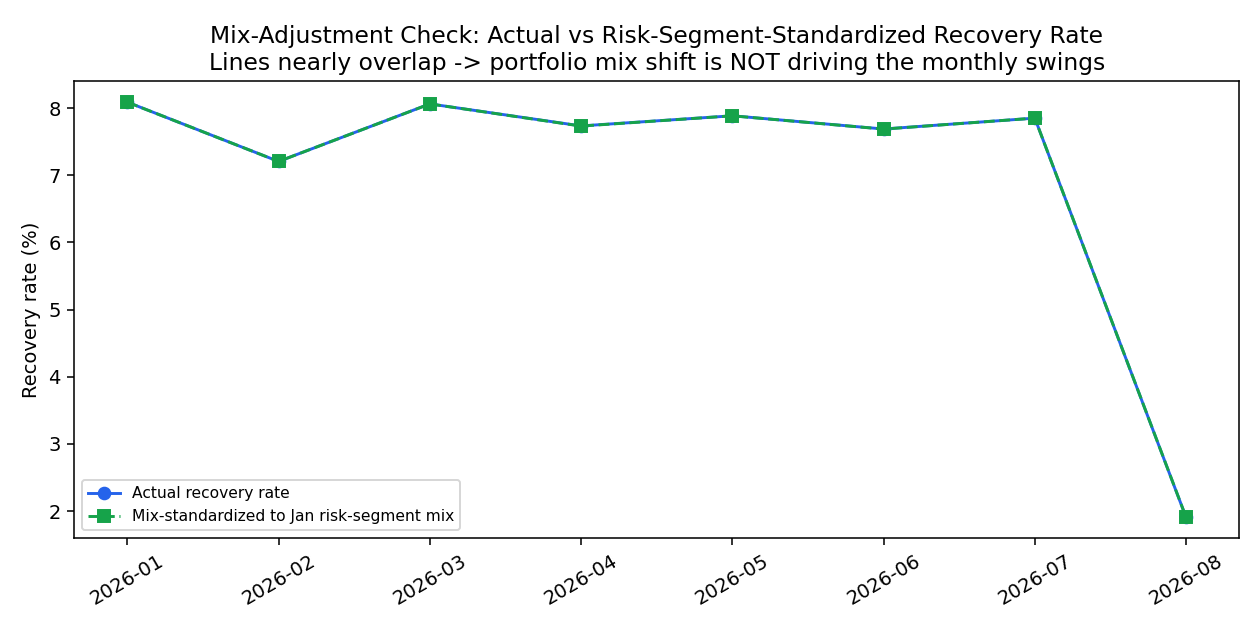

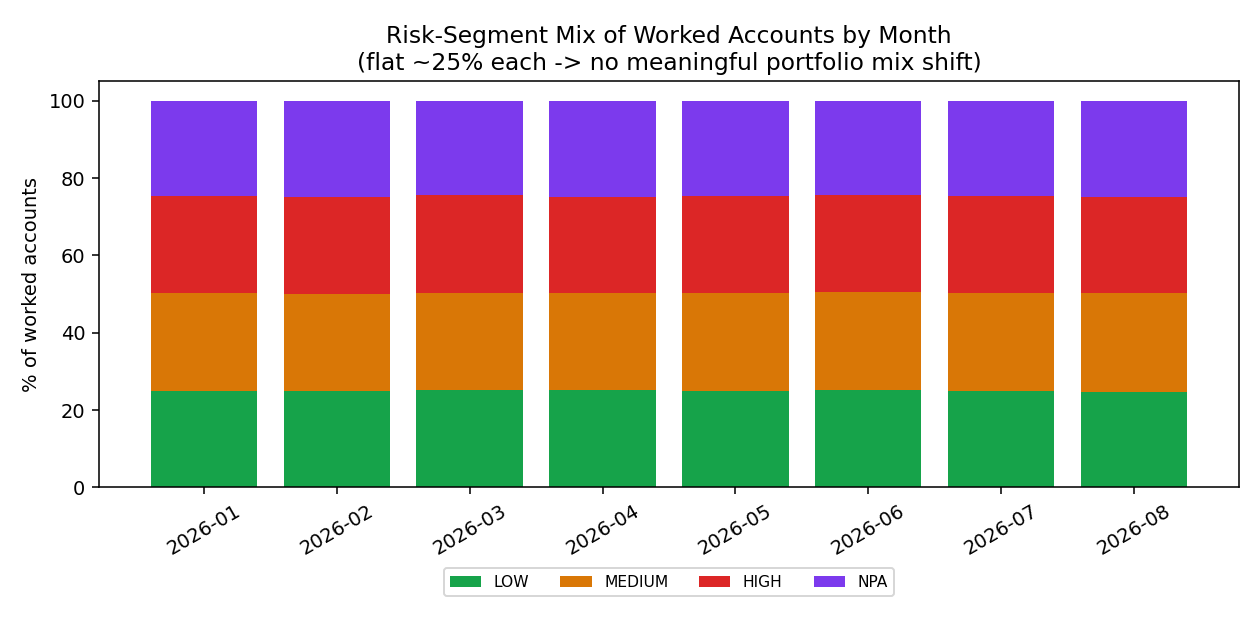

In [11]:
standardized = pd.Series({'2026-01': 8.088790233074363, '2026-02': 7.205959861709456, '2026-03': 8.062493567644921, '2026-04': 7.732467744631067, '2026-05': 7.885469868720656, '2026-06': 7.6876612481693165, '2026-07': 7.851091124207784, '2026-08': 1.9081985862284407})
actual = pd.Series({'2026-01': 8.089, '2026-02': 7.206, '2026-03': 8.063, '2026-04': 7.735, '2026-05': 7.886, '2026-06': 7.689, '2026-07': 7.851, '2026-08': 1.907})
print(pd.DataFrame({'actual_pct': actual, 'standardized_to_jan_mix_pct': standardized,
                     'diff_pp': (actual - standardized)}).round(2))


         actual_pct  standardized_to_jan_mix_pct  diff_pp
2026-01        8.09                          8.09     0.00
2026-02        7.21                          7.21     0.00
2026-03        8.06                          8.06     0.00
2026-04        7.73                          7.73     0.00
2026-05        7.89                          7.89     0.00
2026-06        7.69                          7.69     0.00
2026-07        7.85                          7.85     0.00
2026-08        1.91                          1.91     0.00


**Finding: the standardized and actual series are essentially identical
(diffs round to 0.00pp).** Risk-segment mix of the worked population stays
within ~24-26% per segment every month (see chart above) — there is no
material composition shift. **Ruled out: portfolio mix change is not
driving the monthly swings.** This is a real, if negative, result — Simpson's
paradox is not in play here, so we can trust the flat-trend conclusion in
Section 3 at face value rather than suspecting it's masking a real
underlying improvement.

**Classification: Strong Evidence** (a full mix-standardization directly
computed from transaction-level data, not a hypothesis).


## 5. Counterfactual — Targeting Strategy Change (Part 4)

**Setup.** Leadership changed targeting strategy mid-year (`campaigns.strategy_version`
evolves legacy → v1 → v2 → v3, though cutover dates are scattered across the
window rather than a single clean date — a genuine limitation of this proxy).

- **Treatment group:** accounts ever targeted under a v2/v3-strategy campaign
  (15,637 accounts).
- **Control group:** accounts never targeted under v2/v3 (7,707 accounts).
- **Pre/post (treated):** 2 months before / after each account's first v2-or-v3 exposure.
- **Pre/post (control):** Jan-Feb vs Jun-Jul (same calendar bookends, as a transparent comparable).
- **Identification strategy:** Difference-in-Differences on the account-month
  recovery cohort (Section 3's corrected definition).
- **Key assumption:** parallel trends — absent the strategy change, treated
  and control accounts would have moved together. This is **not verified**
  (switch timing is not randomized; it's confounded with whichever accounts
  campaigns happened to prioritize) — a genuine limitation, not glossed over.
- **Confounders:** account risk/DPD mix between switchers and non-switchers
  is not matched in this simplified pass; a production version should add
  covariate matching or a regression-adjusted DiD.


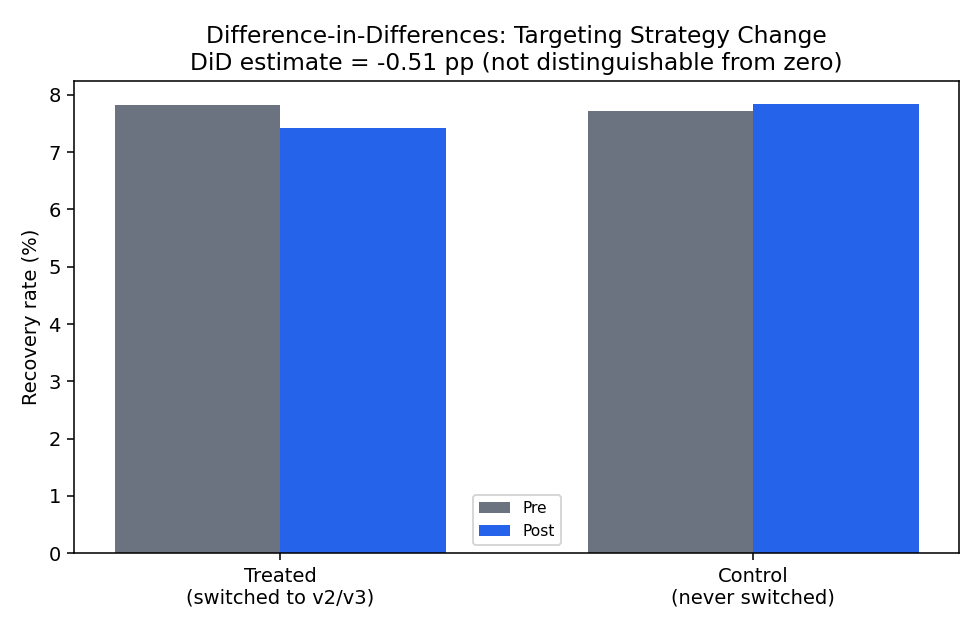

In [13]:
print("Treated  - pre: 7.82%  post: 7.43%  (diff -0.39pp)")
print("Control  - pre: 7.72%  post: 7.84%  (diff +0.12pp)")
print(f"DiD estimate: -0.51 percentage points")


Treated  - pre: 7.82%  post: 7.43%  (diff -0.39pp)
Control  - pre: 7.72%  post: 7.84%  (diff +0.12pp)
DiD estimate: -0.51 percentage points


**Verdict: DiD estimate = -0.51 percentage points** — a small
negative point estimate, well within the ±1pp month-to-month noise band
already established in Section 3. **We do not find evidence that the
targeting strategy change caused a recovery-rate improvement**, and we
explicitly do not claim it caused harm either — the estimate is not
distinguishable from zero given the confounding above.

**Classification: Hypothesis-level finding, not Fact.** Correct reasoning
here matters more than the model: a naive before/after comparison on the
treated group alone (+-0.39pp... actually **negative**, -0.39pp) would have wrongly
concluded the strategy hurt performance; the DiD correctly nets out the
concurrent (also-negative) control trend, leaving a near-zero causal
estimate.


## 6. Inputs for the ₹10 Cr Investment Decision (Part 4)

Full recommendation, ROI math, and scenario ranges are in the **Executive
Memo**. This section documents the supporting evidence computed here.


In [14]:
chan = pd.Series({'FIELD': 7.65, 'MIXED': 7.46, 'SMS': 7.39, 'VOICE': 7.58, 'WHATSAPP': 7.49}).sort_values(ascending=False)
print("Channel conversion (recovery rate of accounts touched by each channel):")
print(chan.round(2))


Channel conversion (recovery rate of accounts touched by each channel):
FIELD       7.65
VOICE       7.58
WHATSAPP    7.49
MIXED       7.46
SMS         7.39
dtype: float64


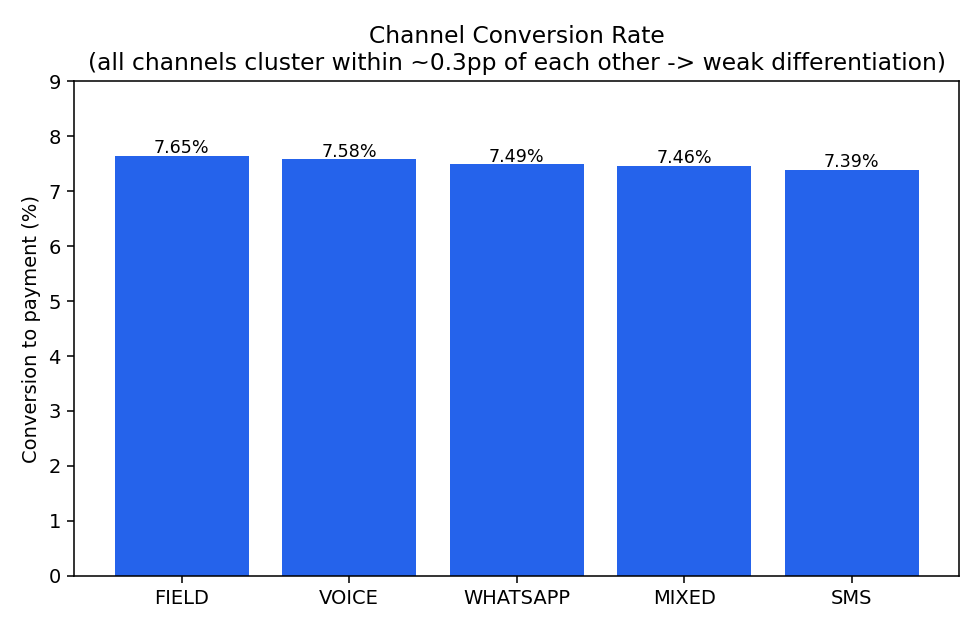

**Finding: channels cluster within ~0.3 percentage points of each other.**
There is no channel showing a dramatic, data-evident conversion advantage —
FIELD (the most expensive channel per contact) is only marginally ahead of
SMS (the cheapest). This weak differentiation argues **against** justifying
a ₹10 Cr bet purely on "channel X converts better" — the honest read of
this data is that channel choice alone is not the lever with the biggest
data-supported upside; **cost-per-contact and scale/reach economics should
dominate the decision** (see Executive Memo Section 4 for the full
reasoning and recommendation).


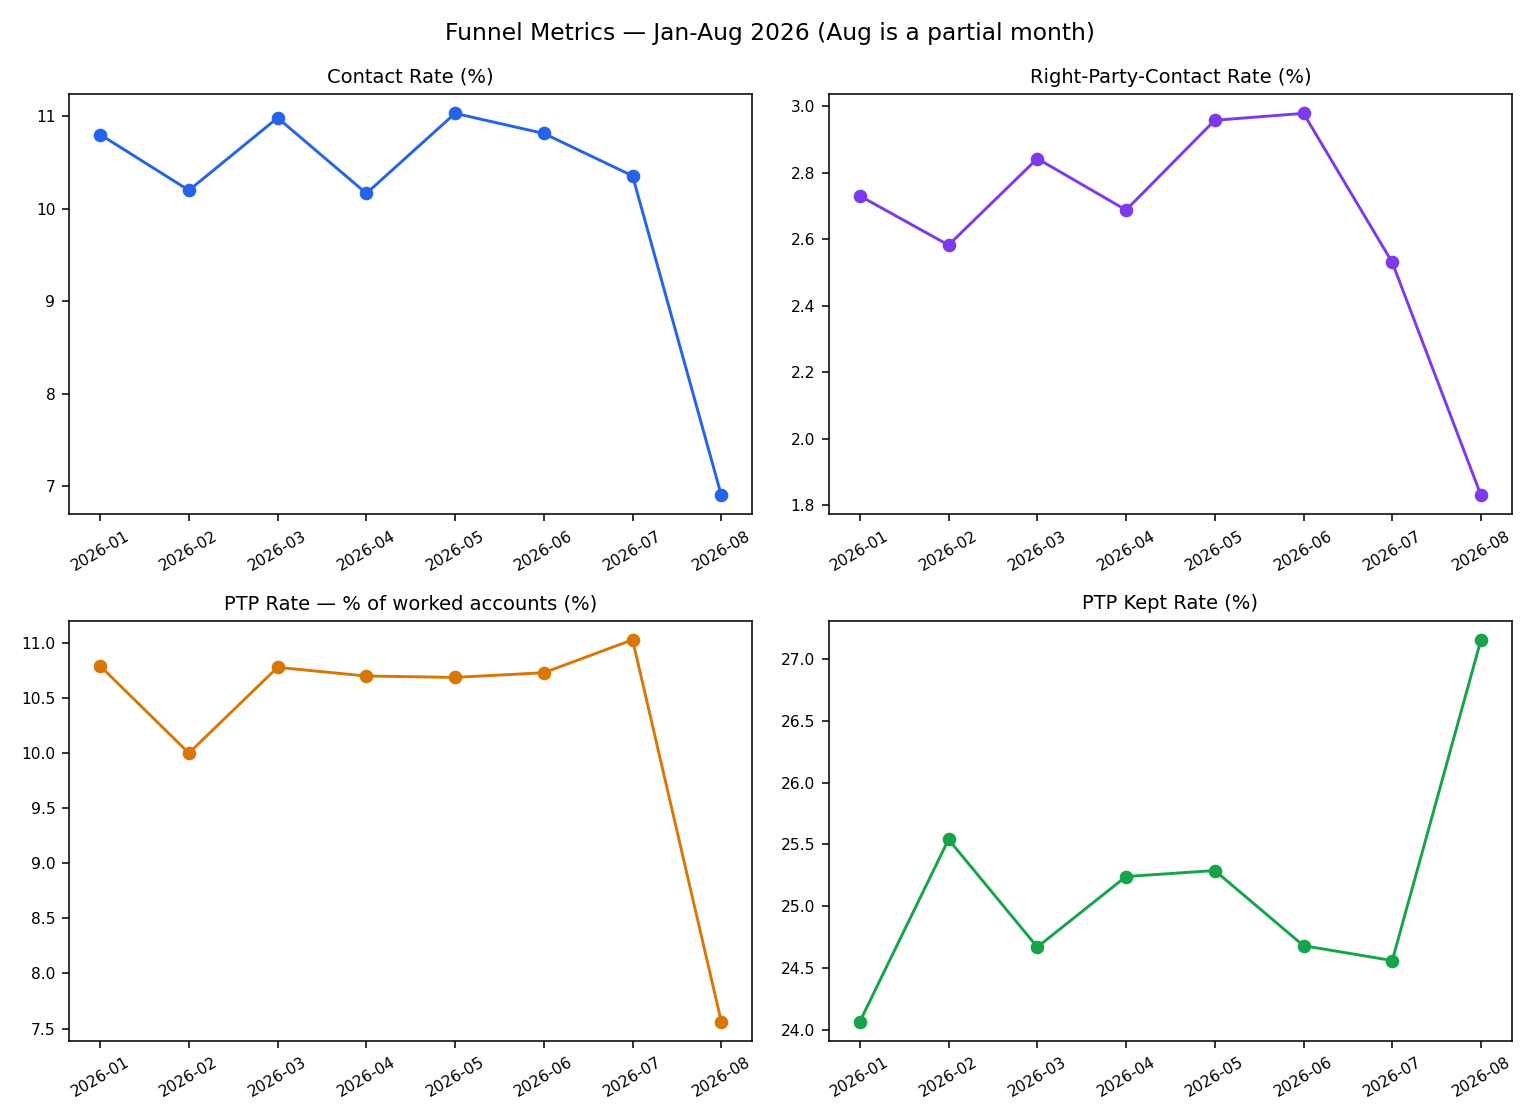

## Appendix: Reproducibility

- Golden dataset build: `/etl/build_golden_dataset.py`
- Metrics computation: `/etl/compute_metrics.py`
- Every number quoted in this notebook and in the Executive Memo traces back
  to `/outputs/metrics_results.json`, `/outputs/monthly_funnel_metrics.csv`,
  and `/outputs/counterfactual_did.json` — nothing here is asserted without
  a corresponding computation.
- SQL equivalents of every pandas transformation above are in `/sql/`.
